In [1]:
# === CELL 1: Imports y dependencias ===
# import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

try:
    from sb3_contrib import RecurrentPPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print("Instala stable-baselines3 antes de ejecutar este notebook.")

# Breakpoint detection basado en RL quasi-supervisado

- **setup**: tomas dos vectores de entrada: el ndvi y un vector categorico que le indica al algoritmo el landcover (0: bosque, 1: no-bosque)
- **idea**: la idea es que el sistema tenga dos estados, y aprende a seguir la serie de tiempo caracteristica de cada uno de ellos.
- **como se usa**: si entrena, se puede cambiar el input de 0 a 1 a ver a que modelo ajusta mejor

### Levanto series de NDVI

In [2]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [3]:
df.columns.values

array(['Unnamed: 0', 'lon', 'lat', 'sitio', 'anio', 'mes', 'nubes',
       '2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
       '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
       '2000-06-25', '2000-07-11', '2000-07-27', '2000-08-12',
       '2000-08-28', '2000-09-13', '2000-09-29', '2000-10-15',
       '2000-10-31', '2000-11-16', '2000-12-02', '2000-12-18',
       '2001-01-01', '2001-01-17', '2001-02-02', '2001-02-18',
       '2001-03-06', '2001-03-22', '2001-04-07', '2001-04-23',
       '2001-05-09', '2001-05-25', '2001-06-10', '2001-06-26',
       '2001-07-12', '2001-07-28', '2001-08-13', '2001-08-29',
       '2001-09-14', '2001-09-30', '2001-10-16', '2001-11-01',
       '2001-11-17', '2001-12-03', '2001-12-19', '2002-01-01',
       '2002-01-17', '2002-02-02', '2002-02-18', '2002-03-06',
       '2002-03-22', '2002-04-07', '2002-04-23', '2002-05-09',
       '2002-05-25', '2002-06-10', '2002-06-26', '2002-07-12',
       '2002-07-28', '2002-08-13', '2002-08-29', '

In [4]:
df.shape

(4610, 437)

Ploteo eventos de deforestacion para algunos pixeles

In [5]:
nSeries = 100

In [6]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

### reconstruyo vector fechas

In [7]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [8]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [9]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [11]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [12]:
ndviDataStart+=1

In [13]:
fechas.shape

(430,)

In [14]:
ndviDataStart

8

### Grafico datos

/tmp/ipykernel_57987/3575788907.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


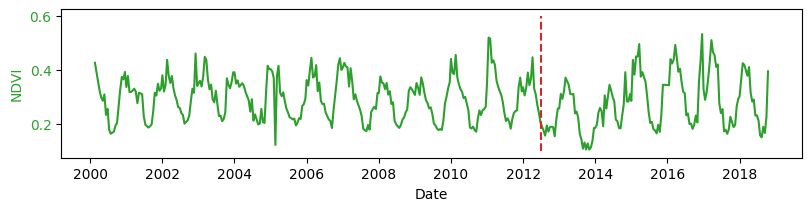

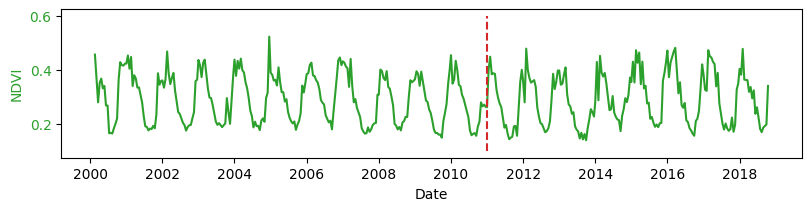

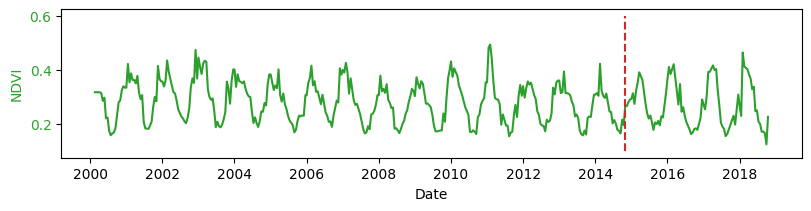

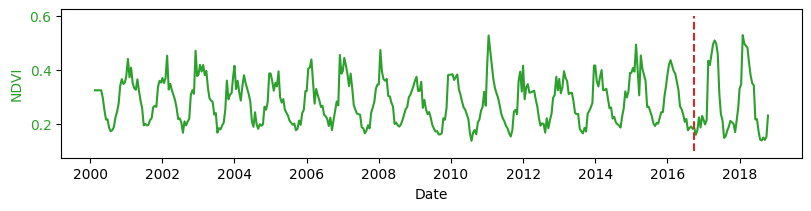

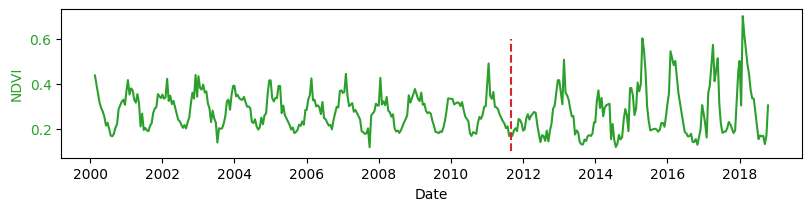

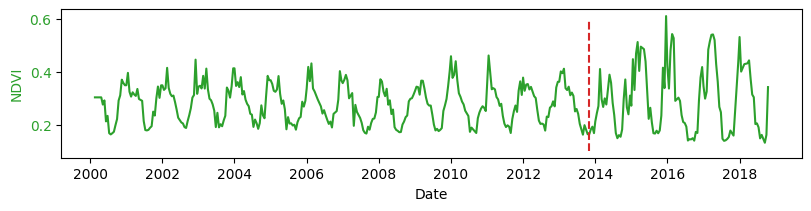

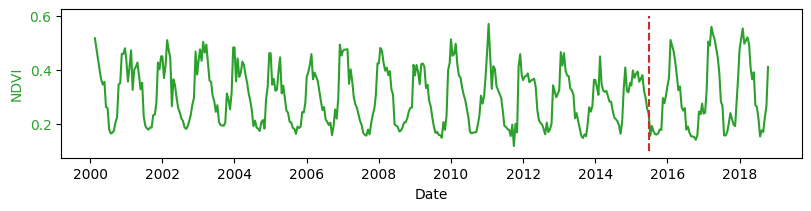

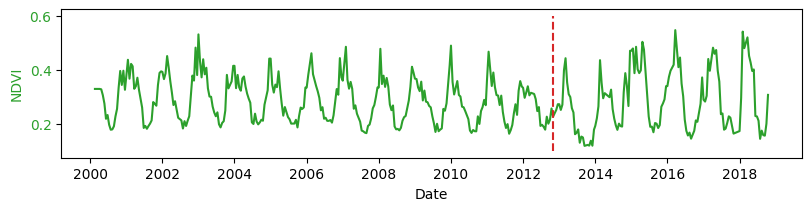

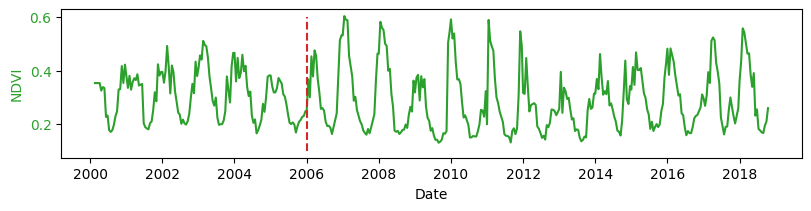

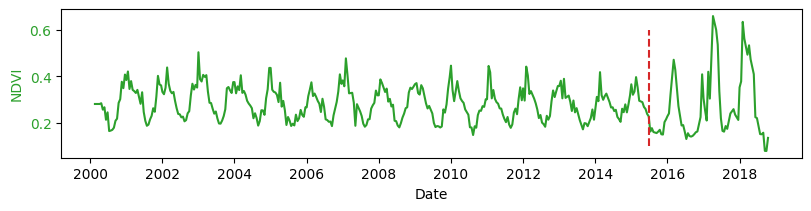

In [15]:
for pixel in testPixel[:10]:

    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    color2 = 'tab:red'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, ndvi, color=color1)
    ax1.vlines(deforestationDate, ymin=0.1, ymax=0.6, color=color2, linestyle='--', label='Deforestación')
    ax1.tick_params(axis='y', labelcolor=color1)

    fig.show()

### Normalizo NDVI

In [16]:
ndvi = df.iloc[:, ndviDataStart-1:]

(array([1.20000e+01, 1.50000e+01, 1.33000e+02, 7.52000e+02, 2.20800e+03,
        5.46100e+03, 2.00020e+04, 5.17820e+04, 1.30641e+05, 1.56308e+05,
        1.59016e+05, 1.38843e+05, 1.22960e+05, 1.16754e+05, 1.15756e+05,
        1.24704e+05, 1.33902e+05, 1.35658e+05, 1.25717e+05, 1.02047e+05,
        8.12060e+04, 6.40260e+04, 4.96910e+04, 3.76700e+04, 2.89070e+04,
        2.13290e+04, 1.53780e+04, 1.19560e+04, 8.82300e+03, 6.39800e+03,
        4.47000e+03, 3.34500e+03, 2.21700e+03, 1.53700e+03, 1.08000e+03,
        6.68000e+02, 4.01000e+02, 2.52000e+02, 1.32000e+02, 7.20000e+01,
        3.80000e+01, 1.50000e+01, 8.00000e+00, 9.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([0.0169  , 0.034888, 0.052876, 0.070864, 0.088852, 0.10684 ,
        0.124828, 0.142816, 0.160804, 0.178792, 0.19678 , 0.214768,
        0.232756, 0.250744, 0.268732, 0.28672 , 0.304708, 0.322696,
        0.340684, 0.358672, 0.37666 , 0.394648, 0.412636, 0.4306

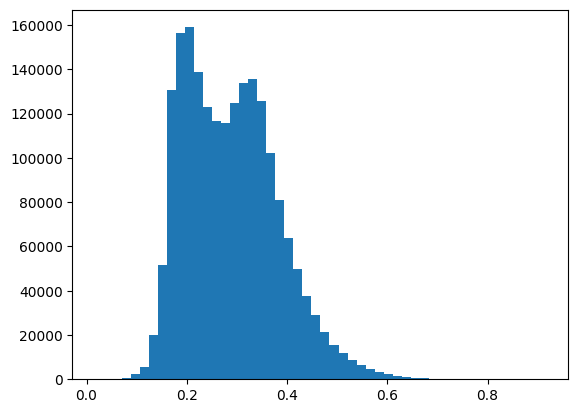

In [17]:
plt.hist(ndvi.values.flatten(), bins=50)

In [18]:
# === CELL 3: Preprocesamiento y split ===

''' 
# Normalización [-1,1] #no me gusta mucho esto
ndvi = df.iloc[:, ndviDataStart-1:].values #df2.iloc[:,1:].values
minv, maxv = ndvi.min(), ndvi.max()
def normalize(x): return 2*(x - minv)/(maxv - minv) - 1
def denormalize(z): return ((z+1)/2*(maxv - minv)) + minv

'''

ndvi = df.iloc[:, ndviDataStart-1:].values #df2.iloc[:,1:].values
ndviMean, ndviStd = ndvi.mean(), ndvi.std()
def normalize(x): return 2*(x - ndviMean)/ndviStd**0.5
def denormalize(z): return (z/2*ndviStd**0.5) + ndviMean

df.iloc[:, ndviDataStart-1:] = df.iloc[:, ndviDataStart-1:].apply(normalize)

(array([1.20000e+01, 1.50000e+01, 1.33000e+02, 7.52000e+02, 2.20800e+03,
        5.46100e+03, 2.00020e+04, 5.17820e+04, 1.30641e+05, 1.56308e+05,
        1.59016e+05, 1.38843e+05, 1.22960e+05, 1.16754e+05, 1.15756e+05,
        1.24704e+05, 1.33902e+05, 1.35658e+05, 1.25717e+05, 1.02047e+05,
        8.12060e+04, 6.40260e+04, 4.96910e+04, 3.76700e+04, 2.89070e+04,
        2.13290e+04, 1.53780e+04, 1.19560e+04, 8.82300e+03, 6.39800e+03,
        4.47000e+03, 3.34500e+03, 2.21700e+03, 1.53700e+03, 1.08000e+03,
        6.68000e+02, 4.01000e+02, 2.52000e+02, 1.32000e+02, 7.20000e+01,
        3.80000e+01, 1.50000e+01, 8.00000e+00, 9.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-1.78497894, -1.66695814, -1.54893734, -1.43091654, -1.31289574,
        -1.19487494, -1.07685414, -0.95883333, -0.84081253, -0.72279173,
        -0.60477093, -0.48675013, -0.36872933, -0.25070853, -0.13268773,
        -0.01466693,  0.10335387,  0.22137467,  0

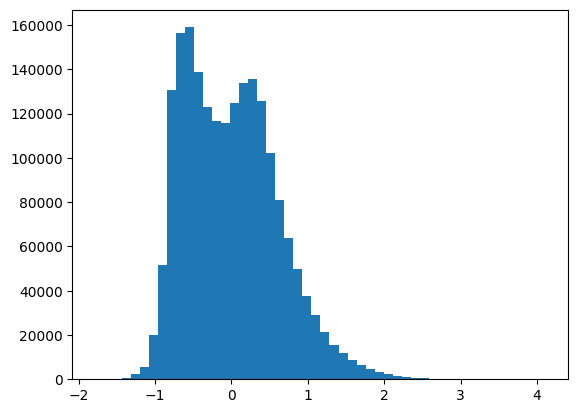

In [19]:
plt.hist(df.iloc[:, ndviDataStart-1:].values.flatten(), bins=50)

In [20]:
# mask = (fechas.year == deforestationDate.year) & (fechas.month == deforestationDate.month)
# deforestationDate = np.where(mask)[0][0]
# train_df = ndvi_norm.iloc[:deforestationDate].reset_index(drop=True)
# test_df = ndvi_norm.iloc[deforestationDate:].reset_index(drop=True)
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.762690,0.506589,0.250488,...,-0.117807,-0.634165,-0.461608,-0.663689,-0.899889,-0.914323,-0.820499,-0.849368,-0.823780,0.554704
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.792871,0.542894,0.292917,...,-0.117807,-0.626291,-0.461608,-0.729956,-0.932694,-0.848056,-0.750952,-0.676156,-0.883486,0.716107
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.830926,0.571107,0.311288,...,-0.006925,-0.550839,-0.497694,-0.651880,-0.881518,-0.848056,-0.832965,-0.878237,-0.883486,0.716107
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.883414,0.645466,0.407517,...,0.031786,-0.620386,-0.415024,-0.672875,-0.874300,-0.831653,-0.899889,-0.927445,-0.826404,0.733166
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.893912,0.651152,0.408392,...,-0.044323,-0.732581,-0.449142,-0.764730,-0.958282,-0.875613,-0.853961,-0.943192,-0.718146,0.678709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.506152,0.506152,0.506152,...,-0.261495,-0.557400,-0.367128,-0.742422,-0.867739,-0.846744,-0.923508,-0.839527,-0.922852,0.323098
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.315224,0.315224,0.315224,...,-0.051540,-0.487196,-0.373033,-0.594142,-0.807377,-0.820499,-0.869708,-0.724051,-0.811314,0.294885
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,1.058595,0.537973,0.017351,...,-0.039074,-0.543622,-0.350726,-0.615794,-0.832965,-0.817875,-0.884142,-0.849368,-0.814594,0.354591
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,1.052034,0.572091,0.092148,...,-0.168984,-0.535092,-0.436020,-0.681404,-0.855273,-0.898576,-0.794911,-0.819515,-0.844119,0.319817


#### Definicion conjuntos de train y test

In [21]:
print('Numero de series analizadas:', len(testPixel))

Numero de series analizadas: 100


In [22]:
fTrain = 0.8
nTrain = int(nSeries*fTrain)

trainSeries = np.random.choice(testPixel, size=nTrain, replace=False)
testSeries = [int(i) for i in testPixel if i not in trainSeries]

In [23]:
trainSeries, testSeries

(array([3974, 1353, 1212, 1534, 3078, 1251, 3133, 1021, 1333, 2771, 2484,
        3695,  659,  761, 3366, 3921, 2855, 4344,  909, 3596, 2895, 2367,
          14, 3798, 1316, 3086, 1127, 2113,   19, 3241, 2780, 1307, 1217,
        4447, 1704, 1444, 1800, 4110, 3609, 1294, 1926, 2583, 2910, 2241,
        2253, 1098, 4147, 1863, 4373,   80, 3842, 2100, 1842,  620, 2257,
        3936,  611, 3218, 2180, 1006, 1673, 4224,  574, 2250,  457,  428,
         181, 4318, 2023, 1449,  351,  477,   11, 3969, 3385,  299, 2362,
        3333, 3533, 4393]),
 [2846,
  3698,
  3458,
  2730,
  1071,
  1506,
  149,
  4420,
  139,
  559,
  2860,
  1300,
  3101,
  2229,
  2160,
  3762,
  3504,
  4255,
  66,
  1922])

In [24]:
df.iloc[0,ndviDataStart-1:]

2000-02-18     0.76269
2000-03-05    0.506589
2000-03-21    0.250488
2000-04-06   -0.005613
2000-04-22   -0.096812
                ...   
2018-08-13   -0.914323
2018-08-29   -0.820499
2018-09-14   -0.849368
2018-09-30    -0.82378
2018-10-16    0.554704
Name: 0, Length: 430, dtype: object

In [25]:
train_list = []
test_list = []

for i in trainSeries:
    ndvi_list = df.iloc[i,ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i] #### Sintetizo serie booleana para indicar que landcover hay
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    train_list.append([ndvi_list, input2]) #pego las dos series

for i in testSeries:
    ndvi_list = df.iloc[i,ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i] #### Sintetizo serie booleana para indicar que landcover hay
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    test_list.append([ndvi_list, input2]) #pego las dos series

ploteo un ejemplo de series + landcover

In [26]:
fechas

DatetimeIndex(['2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
               '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
               '2000-06-25', '2000-07-11',
               ...
               '2018-05-25', '2018-06-10', '2018-06-26', '2018-07-12',
               '2018-07-28', '2018-08-13', '2018-08-29', '2018-09-14',
               '2018-09-30', '2018-10-16'],
              dtype='datetime64[ns]', length=430, freq=None)

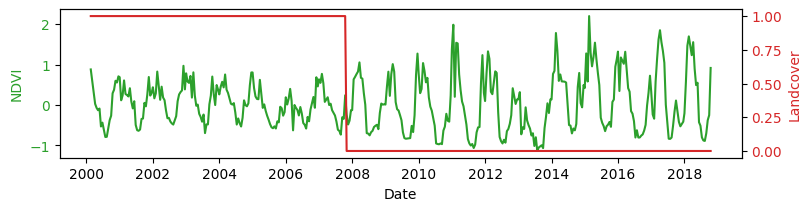

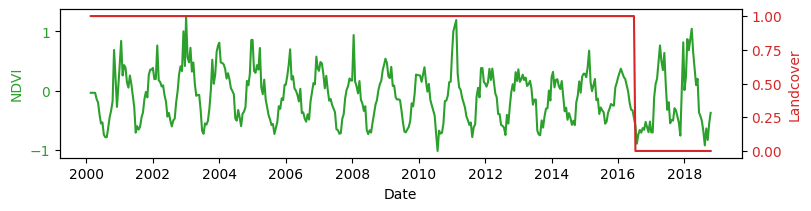

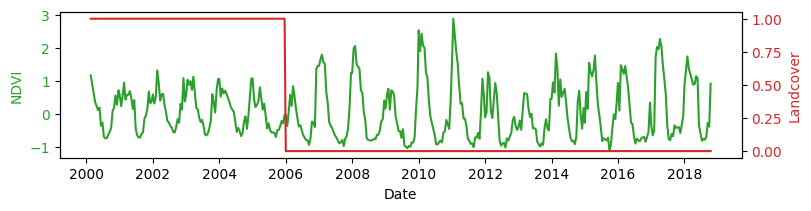

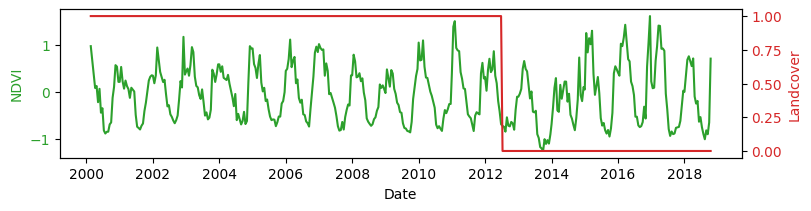

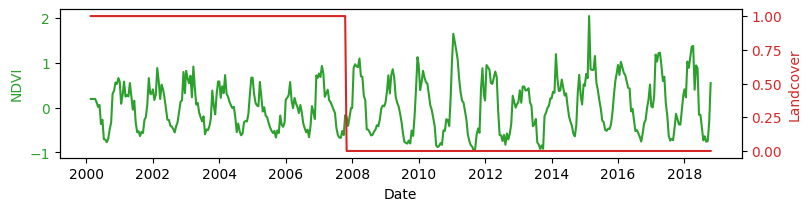

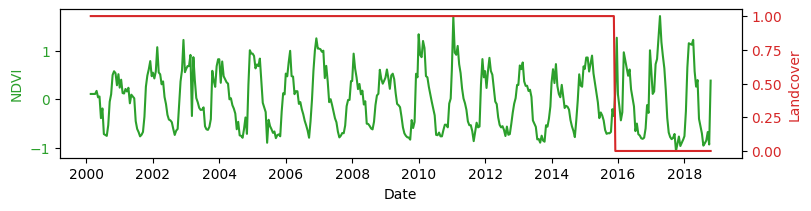

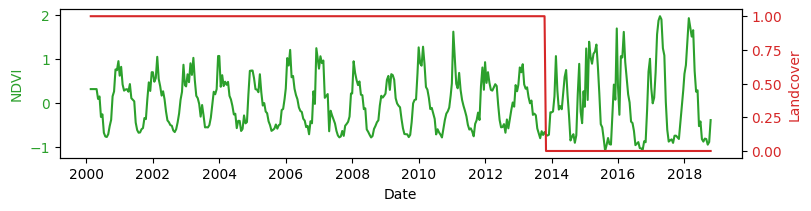

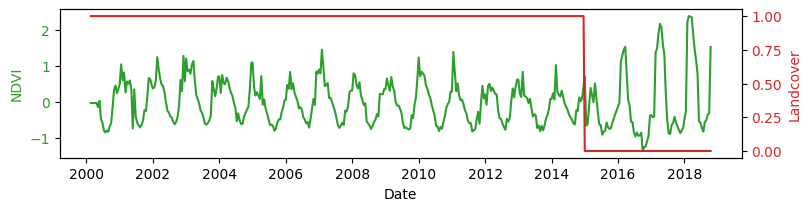

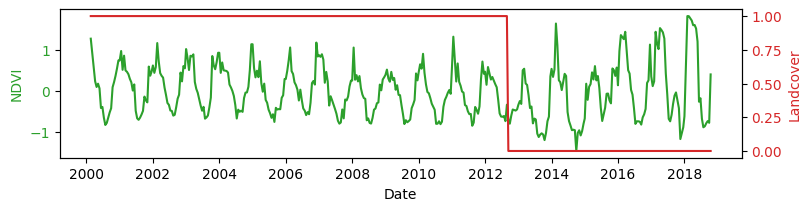

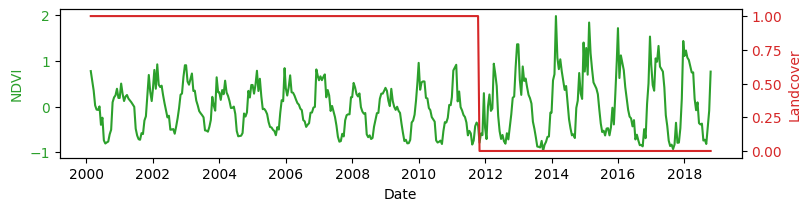

In [27]:
toPlot = np.random.choice(len(trainSeries), size=10)

for index in toPlot:
#index = 114
    fig, ax1 = plt.subplots(layout='constrained', figsize = (8,2)) # use constrained layout

    color1 = 'tab:green'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('NDVI', color=color1)
    ax1.plot(fechas, train_list[index][0], color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)

    # 3. Create the Secondary Y-axis
    ax2 = ax1.twinx()

    # 4. Plot on the Secondary Y-axis
    color2 = 'tab:red'
    ax2.set_ylabel('Landcover', color=color2)
    ax2.plot(fechas, train_list[index][1], color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

### Definicion Entorno gym.Env para que tome stable_baselines3

In [28]:
class MultiSeriesSamplerEnv(gym.Env):
    """Wrapper que muestrea una serie por episodio para entrenar con todas las series."""

    def __init__(self, series_pairs, window=23):
        super().__init__()
        self.series_pairs = series_pairs
        self.n_series = len(series_pairs)
        self.window = window
        # length basada en la longitud mínima de las series NDVI
        self.length = min(len(s[0]) for s in series_pairs)
        # observation: ventana x 2 (NDVI, class)
        self.observation_space = spaces.Box(low=-10.0, high=10.0, shape=(window, 2), dtype=np.float32)
        self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(2,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # elegir una serie al azar para el episodio
        self.current_series = np.random.randint(0, self.n_series)
        self.current_step = self.window
        ndvi = np.array(self.series_pairs[self.current_series][0], dtype=np.float32)[: self.length]
        cat = np.array(self.series_pairs[self.current_series][1], dtype=np.float32)[: self.length]
        self.data = np.stack([ndvi, cat], axis=1)  # shape (length, 2)
        obs = self.data[self.current_step - self.window : self.current_step].copy()
        return obs, {}

    def step(self, action):
        target = self.data[self.current_step]
        reward = -np.mean((action - target) ** 2)
        self.current_step += 1
        terminated = self.current_step >= self.length
        truncated = False
        if not terminated:
            next_obs = self.data[self.current_step - self.window : self.current_step].copy()
        else:
            next_obs = np.zeros((self.window, 2), dtype=np.float32)
        info = {}
        return next_obs, float(reward), terminated, truncated, info

In [29]:
def make_env(series_pairs, window=23):
    """Crea un env vectorizado compatible con stable-baselines3 y RecurrentPPO."""
    def _init():
        env = MultiSeriesSamplerEnv(series_pairs, window=window)
        return env

    # Usar DummyVecEnv sin wrappers adicionales
    # RecurrentPPO puede manejar observaciones multidimensionales
    env = DummyVecEnv([_init])
    return env

Genero el entorno

In [32]:
if len(train_list) > 0:
    env = make_env(train_list, window=23)
    # DummyVecEnv.reset() solo retorna obs (no retorna info)
    obs = env.reset()
    print('Observación (shape):', obs.shape)

Observación (shape): (1, 23, 2)


entreno

In [33]:
# Verificación del entorno antes de entrenar
print("Verificando shapes del entorno...")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Entrenamiento: ajustar parámetros aquí
window = 23
timesteps = 50000  # reducir para prueba rápida
n_steps = 64  # Reducido para series más cortas
lr = 3e-4
batch_size = 32
tensorboard_log = 'logs_recurrentppo'
save_path = 'recurrentppo_ndvi_model'

# Asegurarse de que batch_size < n_steps
if batch_size > n_steps:
    batch_size = n_steps // 2
    print(f"Aajustado batch_size a {batch_size} (debe ser < n_steps)")

print(f"n_steps: {n_steps}, batch_size: {batch_size}")

# (Re)crear el entorno si no existe
if 'env' not in globals() or env.num_envs == 0:
    series = train_list
    env = make_env(series, window=window)

model = RecurrentPPO(
    policy='MlpLstmPolicy',
    env=env,
    verbose=1,
    tensorboard_log=tensorboard_log,
    n_steps=n_steps,
    learning_rate=lr,
    batch_size=batch_size,
)

print("Iniciando entrenamiento...")
model.learn(total_timesteps=timesteps)
model.save(save_path)
print(f'Modelo guardado en: {save_path}')

Verificando shapes del entorno...
Observation space: Box(-10.0, 10.0, (23, 2), float32)
Action space: Box(-10.0, 10.0, (2,), float32)
n_steps: 64, batch_size: 32
Using cpu device
Iniciando entrenamiento...
Logging to logs_recurrentppo/RecurrentPPO_2
-----------------------------
| time/              |      |
|    fps             | 1084 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 64   |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 328          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 128          |
| train/                  |              |
|    approx_kl            | 0.0016035652 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | 0.00298      |
|    learning_rate      

## Evaluacion

### evaluacion con Train (si no anda estamos en el horno)

In [34]:
# Evaluación (adaptada al wrapper MultiSeriesSamplerEnv)
# obs, _ = env.reset()
# preds = []
# rewards = []

# done = False
# while not done:
#     action, _ = model.predict(obs, deterministic=True)
#     obs, reward, done, _, _ = env.step(action)
#     preds.append(action)
#     rewards.append(reward)

# preds = np.array(preds)
# true_vals = env.data[env.window:env.window + len(preds)]

# # Determinar número de variables a plotear a partir de la matriz de verdad
# n_features = true_vals.shape[1]

# import matplotlib.pyplot as plt

# for i in range(n_features):
#     plt.figure(figsize=(10,4))
#     plt.plot(true_vals[:, i], label=f"Real var {i}")
#     plt.plot(preds[:, i], '--', label=f"Predicho {i}")
#     plt.legend()
#     plt.title(f"Comparación variable {i}")
#     plt.tight_layout()
#     plt.show()

### Evaluacion con Test

In [36]:
ntoShow = 5

toShowList = np.random.choice(len(test_list), size=ntoShow, replace=False)

for test_input in toShowList:
    # test_input = [ndvi_array, class_array]
    # test_env = NDVIMultiEnv(test_list[test_input], window=23)
    test_env = env(test_list[test_input], window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    # Graficar NDVI y clase
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(true_vals[:, 0], label="Real NDVI", color='blue')
    ax1.plot(preds[:, 0], '--', label="Predicted NDVI", color='red')
    ax1.set_title("Comparison")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(preds[:, 1], '--', label="Predicted Class", color='orange')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Timestep")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()

TypeError: 'DummyVecEnv' object is not callable

### Evaluaciones raras confundiendo,
#### Es particular, le digo que sigue en estado bosque a ver que hace

In [ ]:
# Crear input3: todos 1 (misma longitud que las series NDVI)
input3 = np.ones(len(train_list[0][0]), dtype=np.float32)  # todos 1

In [ ]:
# for idx, k in enumerate(test_list):
for idx in toShowList:
    k = test_list[idx]
    # test_input = [ndvi_array, class_array]  (k[0], k[1])
    test_input = [k[0], input3]  # usar input3 (todos 1) sobre la serie de test
    test_env = NDVIMultiEnv(test_input, window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    # Determinar fecha de deforestación original para este test (si existe)
    arr_k1 = np.atleast_1d(np.asarray(k[1]))
    zeros = np.where(arr_k1 == 0)[0]
    def_date = fechas[zeros[0]] if zeros.size > 0 else None
    time_axis = fechas[23:23+len(preds)]
    
    # Plot NDVI y clase
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(time_axis, true_vals[:, 0], label="Real NDVI", color='green')
    ax1.plot(time_axis, preds[:, 0], '--', label="Predicted NDVI", color='blue')
    if def_date is not None:
        ax1.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax1.set_title(f"NDVI Comparison (test {idx})")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(time_axis, true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(time_axis, preds[:, 1], '--', label="Predicted Class", color='orange')
    if def_date is not None:
        ax2.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Date")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()

In [ ]:
# Crear input4: todos 0 (misma longitud que las series NDVI)
input4 = np.zeros(len(train_list[0][0]), dtype=np.float32)  # todos 0

In [ ]:
for idx in toShowList:
    k = test_list[idx]
    test_input = [k[0], input4]  # usar input4 (todos 0) sobre la serie de test
    test_env = NDVIMultiEnv(test_input, window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    arr_k1 = np.atleast_1d(np.asarray(k[1]))
    zeros = np.where(arr_k1 == 0)[0]
    def_date = fechas[zeros[0]] if zeros.size > 0 else None
    time_axis = fechas[23:23+len(preds)]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(time_axis, true_vals[:, 0], label="Real NDVI", color='blue')
    ax1.plot(time_axis, preds[:, 0], '--', label="Predicted NDVI", color='red')
    if def_date is not None:
        ax1.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax1.set_title(f"NDVI Comparison (test {idx})")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(time_axis, true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(time_axis, preds[:, 1], '--', label="Predicted Class", color='orange')
    if def_date is not None:
        ax2.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Date")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()